In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
df= pd.read_csv(r'F:\AI-ML-BootCamp\NETSOL WORK\Week_4\titanic_dataset.csv')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df = df.rename(columns={'survived': 'Survived'})

In [10]:
survived_count = df['Survived'].sum()     
total          = df['Survived'].count()  

p_survive = survived_count / total 

In [11]:
Mean = df['Survived'].mean()
print(f"Probability of survival (P(Survived=1)): {p_survive:.4f}")
print(f"Total passengers: {len(df)}")
print(f"Number of survivors: {df['Survived'].sum()}")

print(f"P(Survived=1) = {p_survive:.4f}") 
print(f"P(Died=0)     = {1-p_survive:.4f}")


Probability of survival (P(Survived=1)): 0.3838
Total passengers: 891
Number of survivors: 342
P(Survived=1) = 0.3838
P(Died=0)     = 0.6162


P(X=1) = 0.3838
P(X=0) = 0.6162
Mean   = 0.3838
Variance = 0.2365


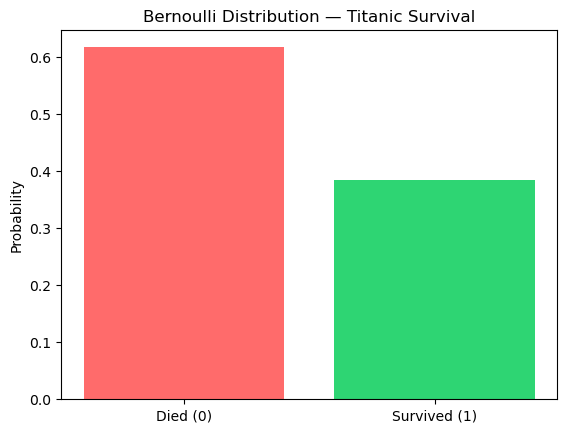

In [12]:

bern = stats.bernoulli(p_survive)

# Probabilities
print(f"P(X=1) = {bern.pmf(1):.4f}")  
print(f"P(X=0) = {bern.pmf(0):.4f}")
print(f"Mean   = {bern.mean():.4f}")    
print(f"Variance = {bern.var():.4f}")  

# Bar chart plot
plt.bar(['Died (0)', 'Survived (1)'],
        [1 - p_survive, p_survive],
        color=['#ff6b6b', '#2ed573'])
plt.title('Bernoulli Distribution — Titanic Survival')
plt.ylabel('Probability')
plt.show()

In [13]:

samples = bern.rvs(1000)

print(f"Simulated survivors: {samples.sum()} out of 1000")
print(f"Simulated rate: {samples.mean():.4f} (actual: {p_survive:.4f})")

Simulated survivors: 386 out of 1000
Simulated rate: 0.3860 (actual: 0.3838)


In [27]:
df.columns

Index(['Survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'Sex_binary'],
      dtype='object')

In [28]:
survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

In [30]:
gender_counts = survivors['sex'].value_counts()

male_survived = gender_counts['male']
female_survived = gender_counts['female']

total_survived = len(survivors)

In [32]:
p_male_survived = male_survived / total_survived
p_female_survived = female_survived / total_survived

print(f"P(Male Survived) = {p_male_survived:.4f}")
print(f"P(Female Survived) = {p_female_survived:.4f}")

P(Male Survived) = 0.3187
P(Female Survived) = 0.6813


In [33]:
print(f"Total survivors: {total_survived}")
print(f"Male survivors: {male_survived}")
print(f"Female survivors: {female_survived}")

print(f"P(Male | Survived)   = {p_male_survived:.4f}")
print(f"P(Female | Survived) = {p_female_survived:.4f}")

Total survivors: 342
Male survivors: 109
Female survivors: 233
P(Male | Survived)   = 0.3187
P(Female | Survived) = 0.6813


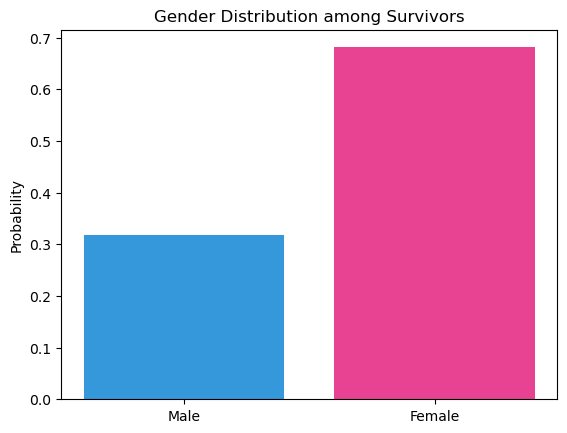

In [34]:
import matplotlib.pyplot as plt

plt.bar(['Male', 'Female'],
        [p_male_survived, p_female_survived],
        color=['#3498db', '#e84393'])

plt.title('Gender Distribution among Survivors')
plt.ylabel('Probability')
plt.show()

Binomial distribution

In [57]:
p = df['Survived'].mean()   # 0.3838
n = 10                       # 10 passengers
print(f"n = {n}, p = {p:.4f}")

n = 10, p = 0.3838


In [59]:
# Binomial distribution 
binom = stats.binom(n, p)

# Basic stats
print(f"Mean     = nxp     = {binom.mean():.4f}")   
print(f"Variance = nxpx(1-p) = {binom.var():.4f}") 

Mean     = nxp     = 3.8384
Variance = nxpx(1-p) = 2.3651


In [61]:
# Exactly 4 logo ke bachne ki probability
print(f"P(X=4)  = {binom.pmf(4):.4f}")
# less then 4 
print(f"P(X<4)  = {binom.cdf(3):.4f}")

# 1 0r more then 1
print(f"P(X>=1) = {1 - binom.pmf(0):.4f}")


P(X=4)  = 0.2494
P(X<4)  = 0.4236
P(X>=1) = 0.9921


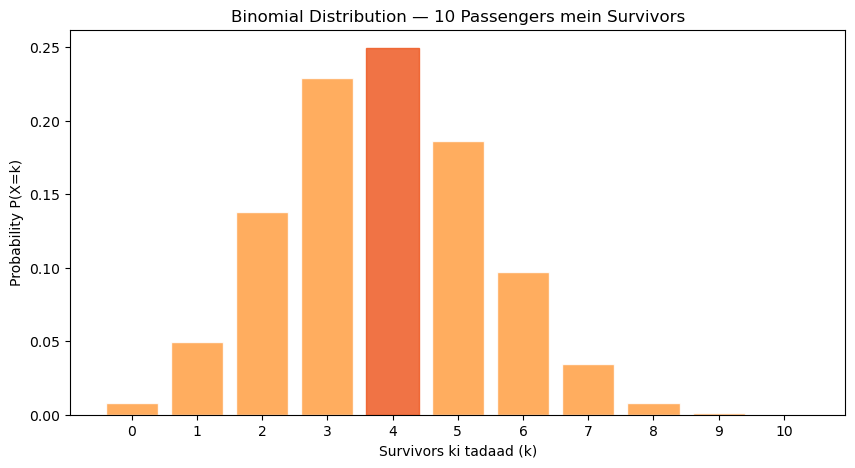

In [ ]:
k_values = np.arange(0, n+1)          
probs    = binom.pmf(k_values)       

plt.figure(figsize=(10, 5))
bars = plt.bar(k_values, probs,
               color='#ff9f43',
               edgecolor='white',
               alpha=0.85)


most_likely = np.argmax(probs)
bars[most_likely].set_color('#ee5a24')

plt.title('Binomial Distribution — 10 Passengers mein Survivors')
plt.xlabel('Survivors ki tadaad (k)')
plt.ylabel('Probability P(X=k)')
plt.xticks(k_values)
plt.show()

Average survivors per group : 3.83
Expected (n×p)              : 3.84


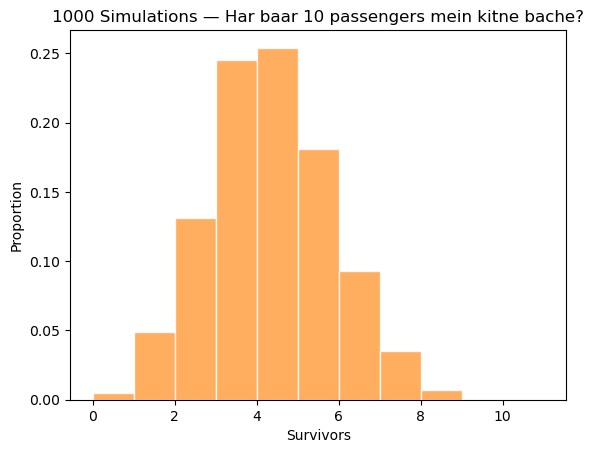

In [64]:
# 1000 baar 10 passengers ka experiment
simulations = binom.rvs(1000)

print(f"Average survivors per group : {simulations.mean():.2f}")
print(f"Expected (n×p)              : {n*p:.2f}")

# Plot
plt.hist(simulations, bins=range(0, 12),
         color='#ff9f43', edgecolor='white',
         alpha=0.85, density=True)
plt.title('1000 Simulations — Har baar 10 passengers mein kitne bache?')
plt.xlabel('Survivors')
plt.ylabel('Proportion')
plt.show()

NORMAL DISTRIBUTION 

In [66]:
age_data = df['age'].dropna()

In [73]:
mu    = age_data.mean()  
sigma = age_data.std()    

print(f"(Mean)    = {mu:.2f}")     
print(f" (Std Dev) = {sigma:.2f}") 

(Mean)    = 29.70
 (Std Dev) = 14.53


In [74]:
normal = stats.norm(mu, sigma)

In [75]:
print(f"P(age < 30) = {normal.cdf(30):.4f}")  
print(f"P(age > 50) = {1 - normal.cdf(50):.4f}") 
print(f"P(20 < age < 40) = {normal.cdf(40) - normal.cdf(20):.4f}") 

P(age < 30) = 0.5083
P(age > 50) = 0.0811
P(20 < age < 40) = 0.5087


In [76]:
# 68% rule — μ ± 1σ
p_68 = normal.cdf(mu + sigma) - normal.cdf(mu - sigma)
print(f"μ ± 1σ mein data = {p_68*100:.1f}%") 

# 95% rule — μ ± 2σ
p_95 = normal.cdf(mu + 2*sigma) - normal.cdf(mu - 2*sigma)
print(f"μ ± 2σ mein data = {p_95*100:.1f}%")  

# 99.7% rule — μ ± 3σ
p_99 = normal.cdf(mu + 3*sigma) - normal.cdf(mu - 3*sigma)
print(f"μ ± 3σ mein data = {p_99*100:.1f}%") 

μ ± 1σ mein data = 68.3%
μ ± 2σ mein data = 95.4%
μ ± 3σ mein data = 99.7%


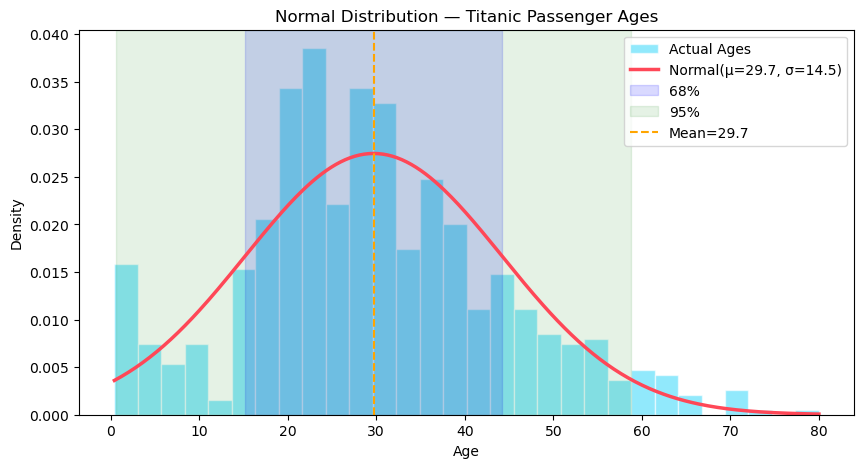

In [ ]:
plt.figure(figsize=(10, 5))

# Actual data histogram
plt.hist(age_data, bins=30, density=True,
         color='#48dbfb', alpha=0.6,
         edgecolor='white',
         label='Actual Ages')

# Normal curve
x = np.linspace(age_data.min(), age_data.max(), 300)
plt.plot(x, normal.pdf(x),
         color='#ff4757', linewidth=2.5,
         label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')

# 3 ranges shade 
plt.axvspan(mu-sigma, mu+sigma,   alpha=0.15, color='blue', label='68%')
plt.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.10, color='green', label='95%')
plt.axvline(mu, color='orange', linestyle='--', label=f'Mean={mu:.1f}')

plt.title('Normal Distribution — Titanic Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

 Poisson Distribution

In [78]:
# Family size banao — SibSp + Parch
df['FamilySize'] = df['sibsp'] + df['parch']

# λ = average family size
lam = df['FamilySize'].mean()
print(f"λ (lambda) = {lam:.4f}") 

λ (lambda) = 0.9046


In [ ]:
poisson = stats.poisson(lam)

# Basic stats
print(f"Mean     = {poisson.mean():.4f}")   
print(f"Variance = {poisson.var():.4f}")    

Mean     = 0.9046
Variance = 0.9046


In [80]:
# Exactly 0 family members
print(f"P(X=0) = {poisson.pmf(0):.4f}") 

# Exactly 1 member
print(f"P(X=1) = {poisson.pmf(1):.4f}")

# 3 ya zyada members
print(f"P(X>=3) = {1 - poisson.cdf(2):.4f}")


P(X=0) = 0.4047
P(X=1) = 0.3661
P(X>=3) = 0.0636


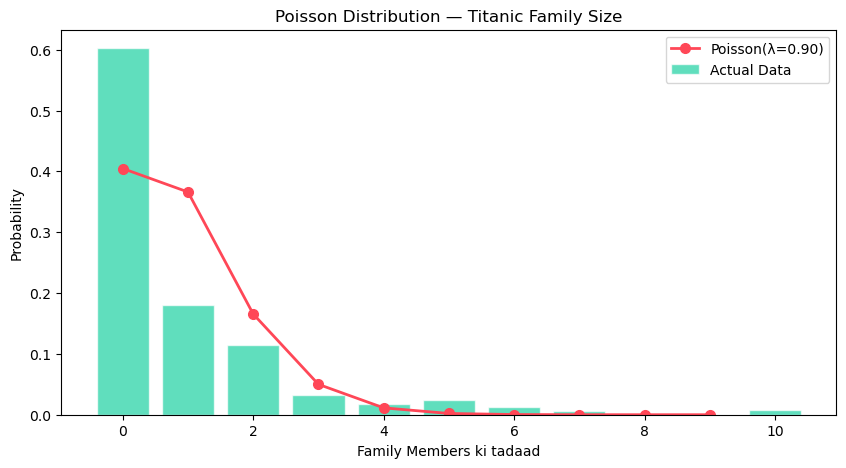

In [ ]:
k_values = np.arange(0, 10)
probs    = poisson.pmf(k_values)

# Actual data
actual = df['FamilySize'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 5))

# Actual bars
plt.bar(actual.index, actual.values,
        color='#1dd1a1', alpha=0.7,
        edgecolor='white', label='Actual Data')

# Theory line
plt.plot(k_values, probs, 'o-',
         color='#ff4757', linewidth=2,
         markersize=7, label=f'Poisson(λ={lam:.2f})')

plt.title('Poisson Distribution — Titanic Family Size')
plt.xlabel('Family Members count')
plt.ylabel('Probability')
plt.legend()
plt.show()

In [83]:
# 891 families simulate 
simulations = poisson.rvs(891)

print(f"Simulated average : {simulations.mean():.4f}")
print(f"Actual    average : {lam:.4f}")
print(f"single travellers  : {(simulations==0).sum()} out of 891")

Simulated average : 0.8900
Actual    average : 0.9046
single travellers  : 351 out of 891


Uniform Distribution

In [85]:
# Ticket numbers 1 to 891 
a = 1      # minimum
b = 891    # maximum

print(f"Range: {a} to {b} ")
print(f"Total passengers: {len(df)}")

Range: 1 to 891 
Total passengers: 891


In [86]:
uniform = stats.uniform(loc=a, scale=b-a)
# loc  = a = starting point
# scale = b-a = range ki width

print(f"Mean     = {uniform.mean():.2f}")   
print(f"Std Dev  = {uniform.std():.2f}")   

Mean     = 446.00
Std Dev  = 256.92


In [87]:
# P(ticket < 445) — pehli half mein ticket
print(f"P(ticket < 445) = {uniform.cdf(445):.4f}")  

# P(ticket 200 se 500 ke beech)
print(f"P(200 < ticket < 500) = {uniform.cdf(500) - uniform.cdf(200):.4f}") 

# P(ticket > 700)
print(f"P(ticket > 700) = {1 - uniform.cdf(700):.4f}")  

P(ticket < 445) = 0.4989
P(200 < ticket < 500) = 0.3371
P(ticket > 700) = 0.2146


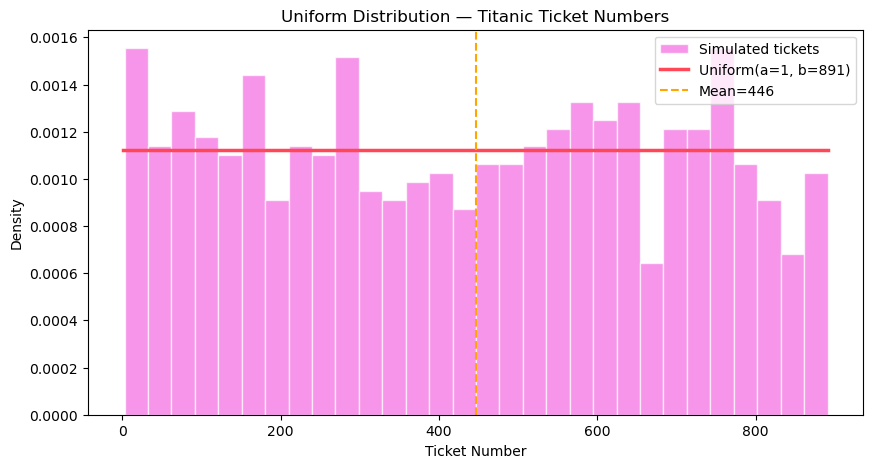

In [ ]:
# 891 random ticket numbers generate karo
samples = uniform.rvs(891)

plt.figure(figsize=(10, 5))

# Simulated data
plt.hist(samples, bins=30,
         density=True,
         color='#f368e0',
         alpha=0.7,
         edgecolor='white',
         label='Simulated tickets')


x = np.linspace(a, b, 300)
plt.plot(x, uniform.pdf(x),
         color='#ff4757',
         linewidth=2.5,
         label=f'Uniform(a={a}, b={b})')

plt.axvline(uniform.mean(), color='orange',
            linestyle='--', label=f'Mean={uniform.mean():.0f}')

plt.title('Uniform Distribution — Titanic Ticket Numbers')
plt.xlabel('Ticket Number')
plt.ylabel('Density')
plt.legend()
plt.show()

Exponential Distribution

In [ ]:
df['fare'] = df['fare'].fillna(df['fare'].median())

fare = df['fare']
mean_fare = fare.mean()

# λ = 1 / mean
lam = 1 / mean_fare

print(f"Mean fare = £{mean_fare:.2f}")  
print(f"λ (lambda) = {lam:.4f}")        

Mean fare = £32.20
λ (lambda) = 0.0311


In [90]:
# scale = 1/λ = mean
exp_dist = stats.expon(scale=mean_fare)

print(f"Mean     = {exp_dist.mean():.2f}")   
print(f"Std Dev  = {exp_dist.std():.2f}")    

Mean     = 32.20
Std Dev  = 32.20


In [91]:
# P(fare < 20) — sasta ticket
print(f"P(fare < £20)  = {exp_dist.cdf(20):.4f}")

# P(fare > 100) — mehenga ticket
print(f"P(fare > £100) = {1 - exp_dist.cdf(100):.4f}")

# P(20 < fare < 50) — middle range
print(f"P(£20 < fare < £50) = {exp_dist.cdf(50) - exp_dist.cdf(20):.4f}")

P(fare < £20)  = 0.4626
P(fare > £100) = 0.0448
P(£20 < fare < £50) = 0.3257


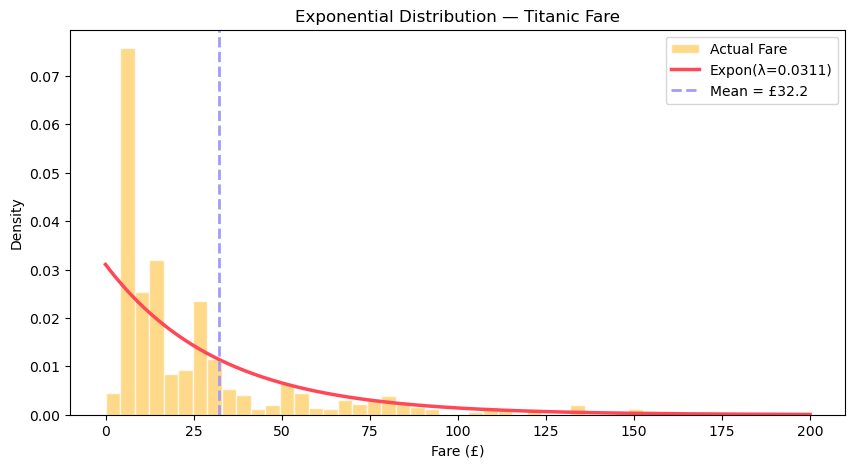

In [92]:
plt.figure(figsize=(10, 5))

# Actual fare data (outliers hata do)
fare_clipped = fare[fare < 200]
plt.hist(fare_clipped, bins=40,
         density=True,
         color='#feca57', alpha=0.7,
         edgecolor='white',
         label='Actual Fare')

# Exponential curve
x = np.linspace(0, 200, 300)
plt.plot(x, exp_dist.pdf(x),
         color='#ff4757', linewidth=2.5,
         label=f'Expon(λ={lam:.4f})')

# Mean line
plt.axvline(mean_fare, color='#a29bfe',
            linestyle='--', linewidth=2,
            label=f'Mean = £{mean_fare:.1f}')

plt.title('Exponential Distribution — Titanic Fare')
plt.xlabel('Fare (£)')
plt.ylabel('Density')
plt.legend()
plt.show()

t-Distribution

In [104]:
# 2 groups banao
survived     = df[df['Survived']==1]['age']
not_survived = df[df['Survived']==0]['age']

print(f"Survived     — Count: {len(survived)},  Mean Age: {survived.mean():.2f}")
print(f"Not Survived — Count: {len(not_survived)}, Mean Age: {not_survived.mean():.2f}")

Survived     — Count: 342,  Mean Age: 28.29
Not Survived — Count: 549, Mean Age: 30.03


In [105]:
# ─── Pehle NaN fix karo ───────────────────────────────
df['age']  = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

# ─── Ab 2 groups banao ────────────────────────────────
male_fare   = df[df['sex']=='male']['fare'].dropna()
female_fare = df[df['sex']=='female']['fare'].dropna()

# ─── Check karo NaN toh nahi? ─────────────────────────
print(f"Male   NaN count : {male_fare.isna().sum()}")    # 0 hona chahiye
print(f"Female NaN count : {female_fare.isna().sum()}")  # 0 hona chahiye
print(f"Male   Count     : {len(male_fare)}")
print(f"Female Count     : {len(female_fare)}")

# ─── Ab t-test karo ───────────────────────────────────
t2, p2 = stats.ttest_ind(male_fare, female_fare)

print(f"\nMale   mean fare : £{male_fare.mean():.2f}")
print(f"Female mean fare : £{female_fare.mean():.2f}")
print(f"t-statistic      = {t2:.4f}")
print(f"p-value          = {p2:.4f}")
print(f"Result: {'Farq REAL hai! ✅' if p2 < 0.05 else 'Farq nahi hai ❌'}")

Male   NaN count : 0
Female NaN count : 0
Male   Count     : 577
Female Count     : 314

Male   mean fare : £25.52
Female mean fare : £44.48
t-statistic      = -5.5291
p-value          = 0.0000
Result: Farq REAL hai! ✅


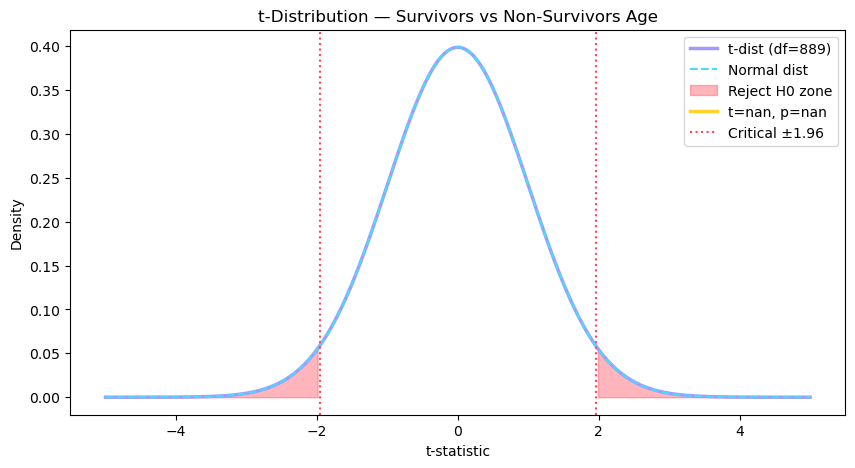

In [106]:
df_val = len(survived) + len(not_survived) - 2  # degrees of freedom

x = np.linspace(-5, 5, 300)
t_dist = stats.t(df=df_val)

plt.figure(figsize=(10, 5))

# t-distribution curve
plt.plot(x, t_dist.pdf(x),
         color='#a29bfe', linewidth=2.5,
         label=f't-dist (df={df_val})')

# Normal curve comparison
plt.plot(x, stats.norm.pdf(x),
         color='#48dbfb', linewidth=1.5,
         linestyle='--', label='Normal dist')

# Critical regions (reject zone) shade karo
t_crit = stats.t.ppf(0.975, df_val)   # 95% confidence
x_left  = x[x < -t_crit]
x_right = x[x >  t_crit]

plt.fill_between(x_left,  t_dist.pdf(x_left),
                 color='#ff4757', alpha=0.4,
                 label='Reject H0 zone')
plt.fill_between(x_right, t_dist.pdf(x_right),
                 color='#ff4757', alpha=0.4)

# Hamara t-statistic
plt.axvline(t_stat, color='#ffd32a',
            linewidth=2.5,
            label=f't={t_stat:.2f}, p={p_value:.4f}')

plt.axvline(-t_crit, color='#ff4757',
            linestyle=':', label=f'Critical ±{t_crit:.2f}')
plt.axvline( t_crit, color='#ff4757', linestyle=':')

plt.title('t-Distribution — Survivors vs Non-Survivors Age')
plt.xlabel('t-statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

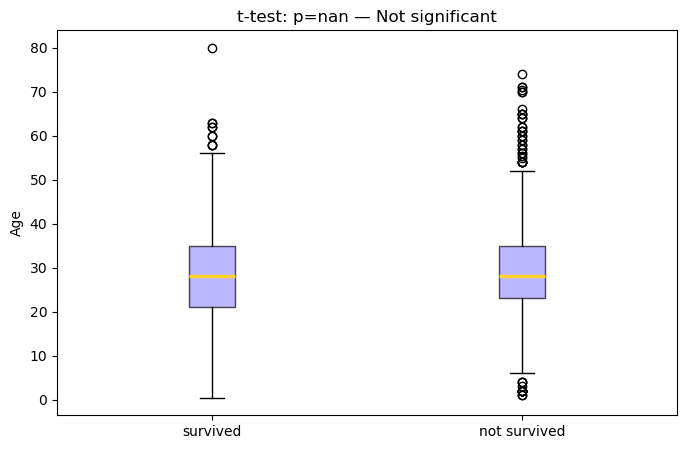

In [107]:
plt.figure(figsize=(8, 5))

plt.boxplot([survived, not_survived],
            labels=['survived', 'not survived'],
            patch_artist=True,
            boxprops=dict(facecolor='#a29bfe', alpha=0.7),
            medianprops=dict(color='#ffd32a', linewidth=2.5))

plt.title(f't-test: p={p_value:.4f} — {"Significant!" if p_value<0.05 else "Not significant"}')
plt.ylabel('Age')
plt.show()